In [ ]:
from collections import OrderedDict
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
import torch.nn.functional as F
from torch import Tensor, nn
import torchvision
from torchvision.models import DenseNet121_Weights, densenet121
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## HYPERPARAMS

In [ ]:
TEST_DATA_DIR = "data\\raw"
MODEL_PATH = "artifacts/normal_lesion_densenet121/best.pt"

# BINARY_THRESHOLD = 0.022
IMG_SIZE = 128
BATCH_SIZE = 16
BINARY_THRESHOLD = 0.5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Stage 1: DenseNet + Capsnet Hybrid

image → DenseNet first 4 blocks → CapsNet head → margin loss

## DenseNet Backbone feature extractor

In [ ]:
# use a base model
# weights = DenseNet121_Weights.IMAGENET1K_V1
# backbone = densenet121(weights=weights)

# load pretrained normal_lesion densenet model
backbone = densenet121(weights=None).to(DEVICE)

# Load weights
weights = torch.load(MODEL_PATH)
state_dict = weights["model_state_dict"] if "model_state_dict" in weights else weights
state_dict = {k.removeprefix("module."): v for k, v in state_dict.items()}

# Convert feature keys from old/new checkpoints into torchvision DenseNet keys.
feature_state_dict = {}
feature_prefixes = (
    "densenet_model.features.",  # old custom checkpoint
    "model.features.",           # current DenseNet121Classifier checkpoint
    "features.",                 # plain torchvision DenseNet checkpoint
)

for key, value in state_dict.items():
    for prefix in feature_prefixes:
        if key.startswith(prefix):
            new_key = "features." + key.removeprefix(prefix)
            feature_state_dict[new_key] = value
            break

print("Loaded feature tensors:", len(feature_state_dict))

missing, unexpected = backbone.load_state_dict(feature_state_dict, strict=False)

print("Missing:", missing)
print("Unexpected:", unexpected)

Loaded feature tensors: 725
Missing: ['classifier.weight', 'classifier.bias']
Unexpected: []


In [ ]:
features = backbone.features
backbone_features = nn.Sequential(
    OrderedDict(
        [
            ("conv0", backbone.features.conv0),
            ("norm0", backbone.features.norm0),
            ("relu0", backbone.features.relu0),
            ("pool0", backbone.features.pool0),
            ("denseblock1", backbone.features.denseblock1),
            ("transition1", backbone.features.transition1),
            ("denseblock2", backbone.features.denseblock2),
            ("transition2", backbone.features.transition2),
            ("denseblock3", backbone.features.denseblock3),
            ("transition3", backbone.features.transition3),
            ("denseblock4", backbone.features.denseblock4),
        ]
    )
).to(DEVICE)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=TEST_DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
test_batch = next(iter(dataloader))
print(f"Batch shape: {test_batch[0].shape}")

Batch shape: torch.Size([16, 3, 128, 128])


In [ ]:
raw = test_batch[0]
data_input = test_batch[0].to(DEVICE)
data_label = test_batch[1].to(DEVICE)
data = data_input
print(f"Input: {data.shape}")
with torch.no_grad():
    for name, layer in backbone_features.named_children():
        data = layer(data)
        print(f"{name}: {data.shape}")
    data = F.relu(data) # We still need this to ensure non-negativity for the binary mask
    print(f"After ReLU: {data.shape}")
data_extracted = data

Input: torch.Size([16, 3, 128, 128])
conv0: torch.Size([16, 64, 64, 64])
norm0: torch.Size([16, 64, 64, 64])
relu0: torch.Size([16, 64, 64, 64])
pool0: torch.Size([16, 64, 32, 32])
denseblock1: torch.Size([16, 256, 32, 32])
transition1: torch.Size([16, 128, 16, 16])
denseblock2: torch.Size([16, 512, 16, 16])
transition2: torch.Size([16, 256, 8, 8])
denseblock3: torch.Size([16, 1024, 8, 8])
transition3: torch.Size([16, 512, 4, 4])
denseblock4: torch.Size([16, 1024, 4, 4])
After ReLU: torch.Size([16, 1024, 4, 4])


## Capsnet

In [ ]:
def squash(s, dim=-1, eps=1e-8):
    """
    Capsule squash activation.
    Input:  (..., capsule_dim)
    Output: (..., capsule_dim)
    """
    squared_norm = (s ** 2).sum(dim=dim, keepdim=True)
    scale = squared_norm / (1.0 + squared_norm)
    return scale * s / torch.sqrt(squared_norm + eps)


class RoutingCapsuleLayer(nn.Module):
    """
    Generic fully-connected capsule layer with dynamic routing.

    Input:
        x: (B, N_in, D_in)

    Output:
        v: (B, N_out, D_out)
    """

    def __init__(self, num_in_caps, in_dim, num_out_caps, out_dim, routing_iters=2):
        super().__init__()

        self.num_in_caps = num_in_caps
        self.in_dim = in_dim
        self.num_out_caps = num_out_caps
        self.out_dim = out_dim
        self.routing_iters = routing_iters

        # W_ij transformation matrix
        # Shape: (1, N_in, N_out, D_out, D_in)
        self.W = nn.Parameter(
            0.01 * torch.randn(1, num_in_caps, num_out_caps, out_dim, in_dim)
        )

    def forward(self, x):
        B = x.size(0)

        # x: (B, N_in, D_in)
        x = x.unsqueeze(2).unsqueeze(-1)
        # x: (B, N_in, 1, D_in, 1)

        W = self.W.expand(B, -1, -1, -1, -1)
        # W: (B, N_in, N_out, D_out, D_in)

        u_hat = torch.matmul(W, x).squeeze(-1)
        # u_hat: (B, N_in, N_out, D_out)

        b_ij = torch.zeros(
            B, self.num_in_caps, self.num_out_caps, device=x.device
        )
        # b_ij: (B, N_in, N_out)

        for r in range(self.routing_iters):
            c_ij = F.softmax(b_ij, dim=2)
            # c_ij: (B, N_in, N_out)

            s_j = (c_ij.unsqueeze(-1) * u_hat).sum(dim=1)
            # s_j: (B, N_out, D_out)

            v_j = squash(s_j, dim=-1)
            # v_j: (B, N_out, D_out)

            if r < self.routing_iters - 1:
                agreement = (u_hat * v_j.unsqueeze(1)).sum(dim=-1)
                # agreement: (B, N_in, N_out)

                b_ij = b_ij + agreement

        return v_j


class DenseNetCapsHead(nn.Module):
    """
    CapsNet head after your 4-DenseBlock feature extractor.

    Expected input:
        feature_map: (B, C, H, W)

    Example for DenseNet121 first 4 blocks:
        feature_map ≈ (B, 1024, 4, 4)

    Flow:
        (B, C, H, W)
        -> reshape to capsules
        -> BN
        -> Capsule layer, 256 capsules
        -> DigitCaps
        -> class probabilities
    """

    def __init__(
        self,
        in_channels=1024,
        feature_h=4,
        feature_w=4,
        num_classes=6,
        primary_caps_dim=8,
        capsule_dim=8,
        digit_caps_dim=16,
        num_capsules=256,
        capsule_routing_iters=2,
        digit_routing_iters=3,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.feature_h = feature_h
        self.feature_w = feature_w
        self.num_classes = num_classes
        self.primary_caps_dim = primary_caps_dim

        flattened_dim = in_channels * feature_h * feature_w

        assert flattened_dim % primary_caps_dim == 0, (
            f"Flattened feature size {flattened_dim} must be divisible "
            f"by primary_caps_dim={primary_caps_dim}"
        )

        self.num_primary_caps = flattened_dim // primary_caps_dim

        self.bn = nn.BatchNorm1d(self.num_primary_caps)

        self.capsule_layer = RoutingCapsuleLayer(
            num_in_caps=self.num_primary_caps,
            in_dim=primary_caps_dim,
            num_out_caps=num_capsules,
            out_dim=capsule_dim,
            routing_iters=capsule_routing_iters,
        )

        self.digit_caps = RoutingCapsuleLayer(
            num_in_caps=num_capsules,
            in_dim=capsule_dim,
            num_out_caps=num_classes,
            out_dim=digit_caps_dim,
            routing_iters=digit_routing_iters,
        )

    def forward(self, feature_map):
        B = feature_map.size(0)

        # (B, C, H, W) -> (B, C*H*W)
        x = feature_map.flatten(start_dim=1)

        # (B, C*H*W) -> (B, N_primary_caps, D_primary)
        x = x.view(B, self.num_primary_caps, self.primary_caps_dim)

        # BatchNorm over capsule index
        x = self.bn(x)

        # Capsule layer
        x = self.capsule_layer(x)
        # (B, 256, capsule_dim)

        # DigitCaps
        digit_caps = self.digit_caps(x)
        # (B, num_classes, digit_caps_dim)

        # Class probability = capsule length
        probs = torch.norm(digit_caps, dim=-1)
        # (B, num_classes)

        return probs, digit_caps

In [ ]:
class CapsuleMarginLoss(nn.Module):
    """
    Margin loss from Sabour et al., used by the paper.

    L_k = T_k max(0, m+ - ||v_k||)^2
        + λ(1 - T_k) max(0, ||v_k|| - m-)^2
    """

    def __init__(self, m_plus=0.9, m_minus=0.1, lambda_=0.5):
        super().__init__()
        self.m_plus = m_plus
        self.m_minus = m_minus
        self.lambda_ = lambda_

    def forward(self, probs, labels):
        """
        probs:  (B, num_classes), capsule lengths
        labels: (B,), integer class labels
        """
        num_classes = probs.size(1)
        one_hot = F.one_hot(labels, num_classes=num_classes).float()

        positive_loss = one_hot * F.relu(self.m_plus - probs).pow(2)
        negative_loss = (1.0 - one_hot) * F.relu(probs - self.m_minus).pow(2)

        loss = positive_loss + self.lambda_ * negative_loss
        return loss.sum(dim=1).mean()

In [ ]:
probs

tensor([[8.3549e-10, 1.4718e-09],
        [1.9140e-09, 2.4714e-09],
        [4.8501e-09, 4.7748e-09],
        [3.9171e-09, 2.0293e-09],
        [1.7090e-09, 8.1268e-10],
        [2.4446e-09, 3.9612e-09],
        [1.3922e-09, 9.5173e-10],
        [2.8437e-10, 9.3277e-10],
        [1.9792e-09, 3.1503e-09],
        [5.3202e-09, 7.6150e-09],
        [1.4782e-09, 1.6608e-09],
        [3.1224e-09, 2.3477e-09],
        [2.9661e-09, 1.4566e-09],
        [2.2187e-09, 2.0548e-09],
        [1.5611e-09, 1.9500e-09],
        [4.4971e-09, 3.2306e-09]], grad_fn=<LinalgVectorNormBackward0>)

In [ ]:
caps_head = DenseNetCapsHead(
    in_channels=1024,
    feature_h=4,
    feature_w=4,
    num_classes=2,
    num_capsules=256,
    capsule_routing_iters=2,
    digit_routing_iters=3,
).to(DEVICE)

criterion = CapsuleMarginLoss(lambda_=0.5).to(DEVICE)

# expected: (5, 1024, 4, 4)

probs, digit_caps = caps_head(data)

loss = criterion(probs, data_label)
loss.backward()

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# Lesion filter

First, we do global average pooling

In [39]:
# data_pooled = F.adaptive_avg_pool2d(data, data.shape[2:])
data_pooled = torch.mean(data, dim = 1)
data_pooled.shape

torch.Size([16, 8, 8])

Then, we binarize it.

In [40]:
import cv2
_, data_binary = cv2.threshold(data_pooled.cpu().detach().numpy(), BINARY_THRESHOLD, 1, cv2.THRESH_BINARY)
# remember, i use binary_inv because the results that i want for the mask is inverted maybe because im using untrained weights rn.
data_binary = torch.from_numpy(data_binary).to(data.device)
data_binary.shape

torch.Size([16, 8, 8])

Next, we can first visuualize the raw image, pooled, and binary data side by side to see the difference.

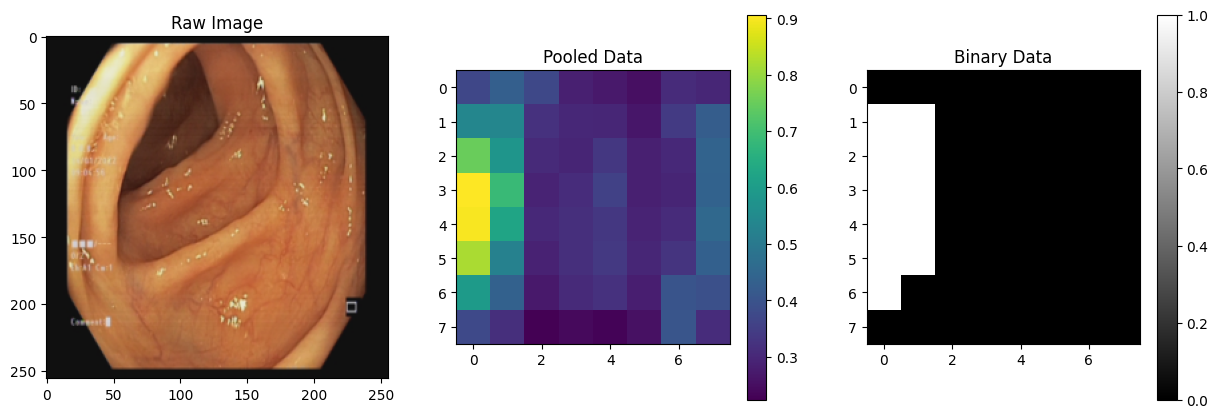

In [41]:
index = 0
img_binary = data_binary[index]
img_pooled = data_pooled[index]
raw_img = raw[index]
# Transpose the raw image to (224, 224, 3) for visualization
raw_img = raw_img.permute(1, 2, 0)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(raw_img.cpu().detach().numpy())
axs[0].set_title("Raw Image")
axs[1].imshow(img_pooled.cpu().detach().numpy(), cmap='viridis')
axs[1].set_title("Pooled Data")
axs[2].imshow(img_binary.cpu().detach().numpy(), cmap='gray')
axs[2].set_title("Binary Data")

# set colorbar for pooled and binary data (make colorbar only range from 0 to 1)
fig.colorbar(axs[1].imshow(img_pooled.cpu().detach().numpy(), cmap='viridis'), ax=axs[1])
fig.colorbar(axs[2].imshow(img_binary.cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1), ax=axs[2])
plt.show()

Next is check connectivity and aspect ratio

In [42]:
def _four_connected_neighbors(mask: torch.Tensor) -> torch.Tensor:
    neighbors = torch.zeros_like(mask, dtype=torch.bool)

    neighbors[1:, :] |= mask[:-1, :]
    neighbors[:-1, :] |= mask[1:, :]
    neighbors[:, 1:] |= mask[:, :-1]
    neighbors[:, :-1] |= mask[:, 1:]

    return neighbors


def _square_bbox_mask(
    binary_mask: torch.Tensor,
    y_min: torch.Tensor,
    x_min: torch.Tensor,
    y_max: torch.Tensor,
    x_max: torch.Tensor,
) -> torch.Tensor:
    height, width = binary_mask.shape
    device = binary_mask.device

    bbox_height = y_max - y_min + 1
    bbox_width = x_max - x_min + 1
    side = torch.maximum(bbox_height, bbox_width)

    max_side = torch.tensor(min(height, width), device=device, dtype=side.dtype)
    side = torch.minimum(side, max_side)

    y_start = y_min - (side - bbox_height) // 2
    x_start = x_min - (side - bbox_width) // 2

    zero = torch.zeros((), device=device, dtype=side.dtype)
    max_y_start = torch.tensor(height, device=device, dtype=side.dtype) - side
    max_x_start = torch.tensor(width, device=device, dtype=side.dtype) - side

    y_start = torch.minimum(torch.maximum(y_start, zero), max_y_start)
    x_start = torch.minimum(torch.maximum(x_start, zero), max_x_start)
    y_end = y_start + side - 1
    x_end = x_start + side - 1

    ys = torch.arange(height, device=device).view(-1, 1)
    xs = torch.arange(width, device=device).view(1, -1)
    return (ys >= y_start) & (ys <= y_end) & (xs >= x_start) & (xs <= x_end)


def separate_connected_components_as_square_boxes(
    binary_mask: torch.Tensor,
    aspect_ratio_threshold: float = 4.0,
    min_area: int = 2,
) -> torch.Tensor:
    """
    Returns square bool masks around each connected component.

    Args:
        binary_mask: 2D tensor [H, W].
        aspect_ratio_threshold: keeps component bboxes whose width / height is between
            1 / threshold and threshold.
        min_area: minimum component pixel count before creating a square box.

    Returns:
        Bool tensor [num_square_boxes, H, W].
    """
    if binary_mask.dim() != 2:
        raise ValueError(f"Expected a 2D mask [H, W], got shape {tuple(binary_mask.shape)}")

    binary_mask = binary_mask.bool()
    unvisited = binary_mask.clone()
    square_boxes = []

    while unvisited.any():
        seed_index = torch.nonzero(unvisited, as_tuple=False)[0]
        y, x = seed_index[0], seed_index[1]

        component = torch.zeros_like(binary_mask, dtype=torch.bool)
        frontier = torch.zeros_like(binary_mask, dtype=torch.bool)

        component[y, x] = True
        frontier[y, x] = True
        unvisited[y, x] = False

        while frontier.any():
            neighbors = _four_connected_neighbors(frontier)
            new_frontier = neighbors & unvisited

            if not new_frontier.any():
                break

            component |= new_frontier
            unvisited &= ~new_frontier
            frontier = new_frontier

        area = component.sum()
        if area < min_area:
            continue

        coords = torch.nonzero(component, as_tuple=False)
        y_min, x_min = coords.min(dim=0).values
        y_max, x_max = coords.max(dim=0).values

        width = (x_max - x_min + 1).float()
        height = (y_max - y_min + 1).float()
        aspect_ratio = width / height.clamp_min(1.0)

        if (
            aspect_ratio < aspect_ratio_threshold
            and aspect_ratio > 1.0 / aspect_ratio_threshold
        ):
            square_boxes.append(_square_bbox_mask(binary_mask, y_min, x_min, y_max, x_max))

    if not square_boxes:
        return torch.empty(
            (0, *binary_mask.shape),
            dtype=torch.bool,
            device=binary_mask.device,
        )

    return torch.stack(square_boxes, dim=0)


In [43]:
# def separate_connected_components(
#     binary_mask: torch.Tensor,
#     aspect_ratio_threshold: float = 4.0,
#     min_area: int = 2,
# ) -> torch.Tensor:
#     return separate_connected_components_as_square_boxes(
#         binary_mask,
#         aspect_ratio_threshold=aspect_ratio_threshold,
#         min_area=min_area,
#     )

In [48]:
def resize_mask_to_input_image(
    square_mask: torch.Tensor,
    image_size: tuple[int, int],
) -> torch.Tensor:
    """Resize a low-resolution [h, w] bool mask to the input image [H, W]."""
    if square_mask.dim() != 2:
        raise ValueError(f"Expected square_mask [h, w], got {tuple(square_mask.shape)}")

    resized_mask = F.interpolate(
        square_mask.bool().float().unsqueeze(0).unsqueeze(0),
        size=image_size,
        mode="nearest",
    ).squeeze(0).squeeze(0)
    return resized_mask.bool()


def extract_zoomed_masked_input_image(
    input_image: torch.Tensor,
    square_mask: torch.Tensor,
    mode: str = "bilinear",
) -> tuple[torch.Tensor, torch.Tensor]:
    """Resize mask to input size, crop the masked region, then zoom it to [C, H, W]."""
    if input_image.dim() != 3:
        raise ValueError(f"Expected input_image [C, H, W], got {tuple(input_image.shape)}")

    image_mask = resize_mask_to_input_image(square_mask, input_image.shape[-2:])
    masked_image = input_image * image_mask.unsqueeze(0).to(dtype=input_image.dtype)

    coords = torch.nonzero(image_mask, as_tuple=False)
    if coords.numel() == 0:
        return torch.zeros_like(input_image), image_mask

    y_min, x_min = coords.min(dim=0).values.tolist()
    y_max, x_max = coords.max(dim=0).values.tolist()
    crop = masked_image[:, y_min : y_max + 1, x_min : x_max + 1]

    interpolate_kwargs = {"size": input_image.shape[-2:], "mode": mode}
    if mode in {"linear", "bilinear", "bicubic", "trilinear"}:
        interpolate_kwargs["align_corners"] = False
    zoomed_image = F.interpolate(crop.unsqueeze(0), **interpolate_kwargs).squeeze(0)
    return zoomed_image, image_mask


lesion_candidates = []
lesion_candidate_masks = []

for i, img in enumerate(data_binary):
    candidate_list = []
    mask_list = []
    les_cand = separate_connected_components_as_square_boxes(img, min_area=2)
    print(f"img idx-{i}: {len(les_cand)} components")
    if len(les_cand) == 0:
        lesion_candidates.append([])
        lesion_candidate_masks.append([])
        continue
    for mask in les_cand:
        masked_image, resized_mask = extract_zoomed_masked_input_image(data_input[i], mask)
        candidate_list.append(masked_image)
        mask_list.append(resized_mask)
    lesion_candidates.append(candidate_list) # shape: [batch][num_les_cand_per_img], each image is [3, 128, 128]
    lesion_candidate_masks.append(mask_list) # shape: [batch][num_les_cand_per_img], each mask is [128, 128]


img idx-0: 1 components
img idx-1: 0 components
img idx-2: 1 components
img idx-3: 2 components
img idx-4: 1 components
img idx-5: 1 components
img idx-6: 2 components
img idx-7: 1 components
img idx-8: 1 components
img idx-9: 2 components
img idx-10: 1 components
img idx-11: 2 components
img idx-12: 1 components
img idx-13: 1 components
img idx-14: 1 components
img idx-15: 1 components


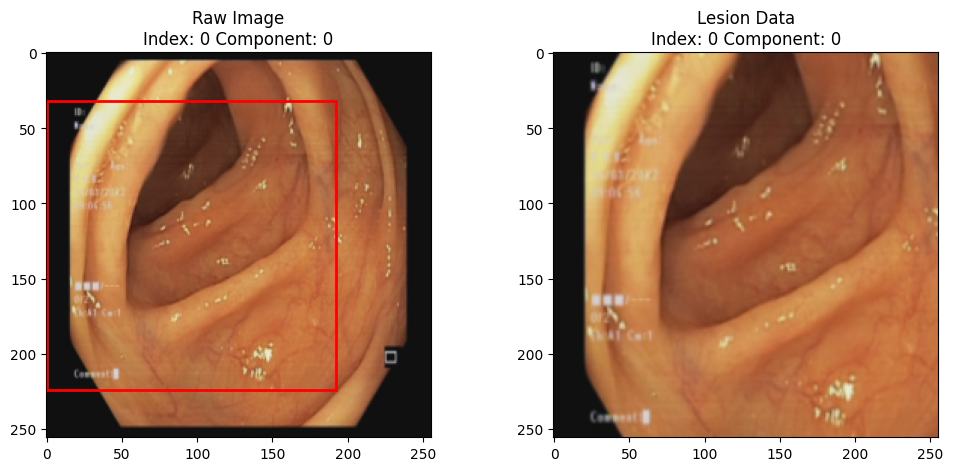

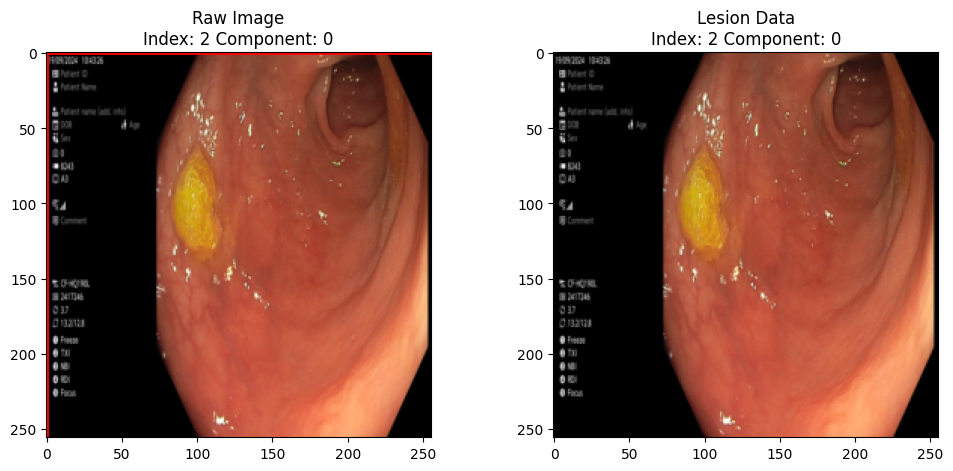

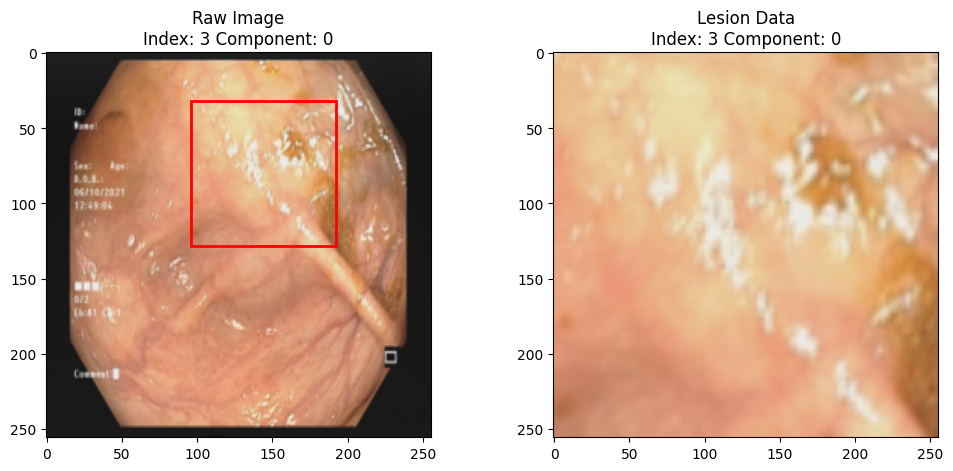

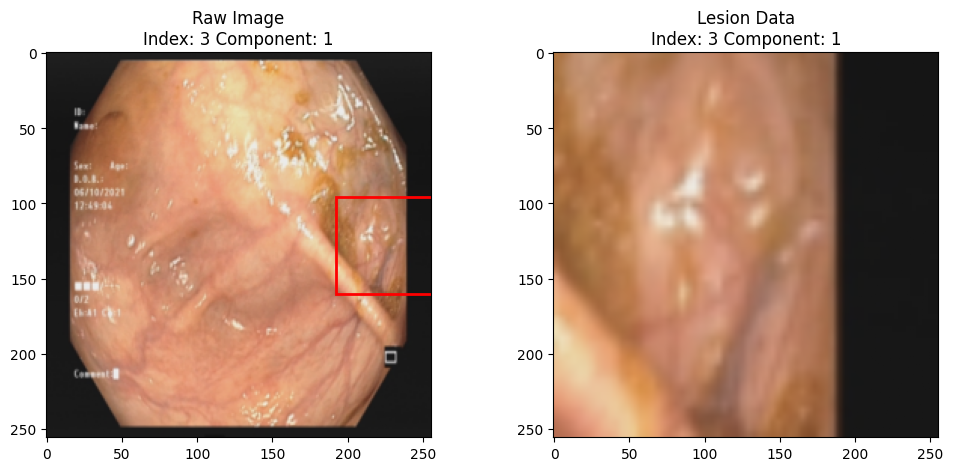

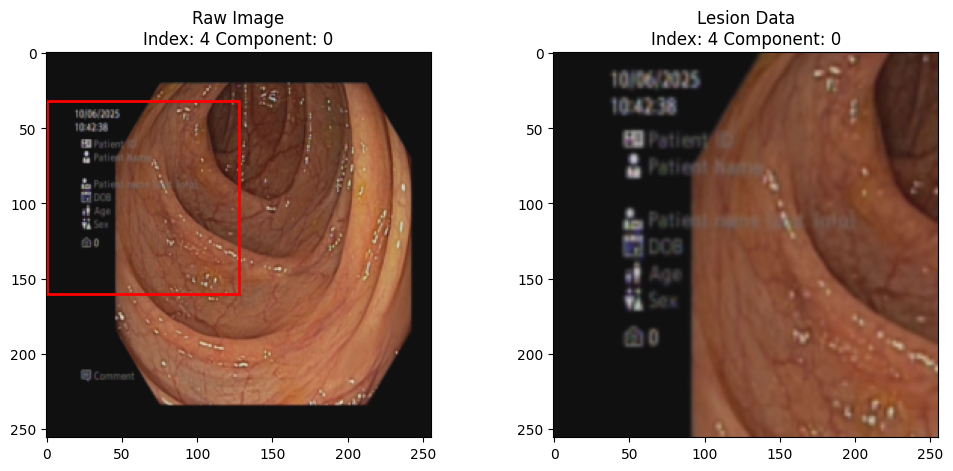

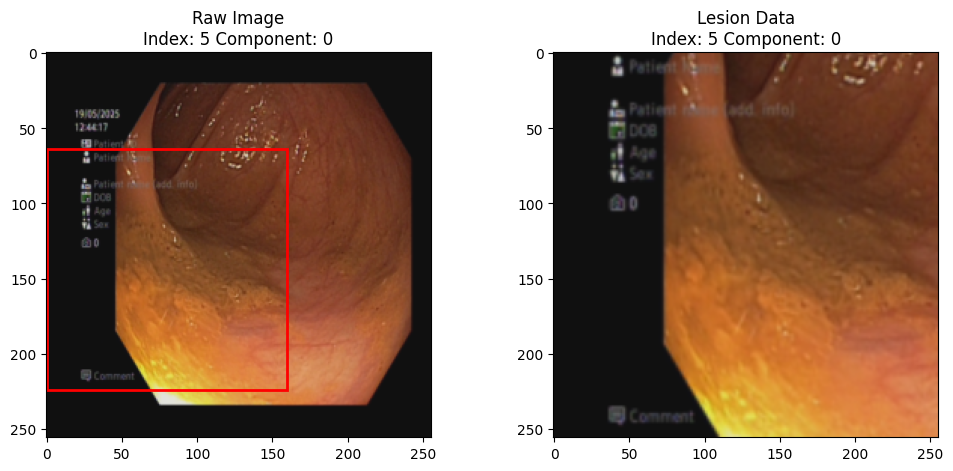

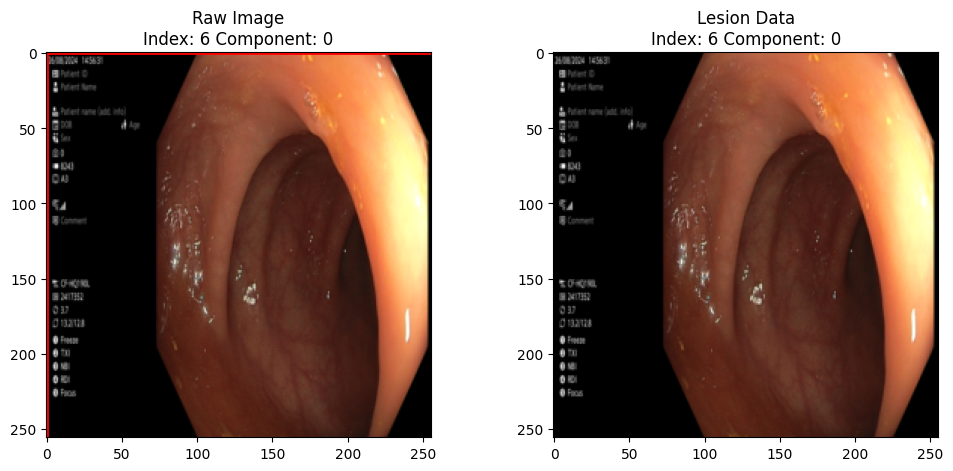

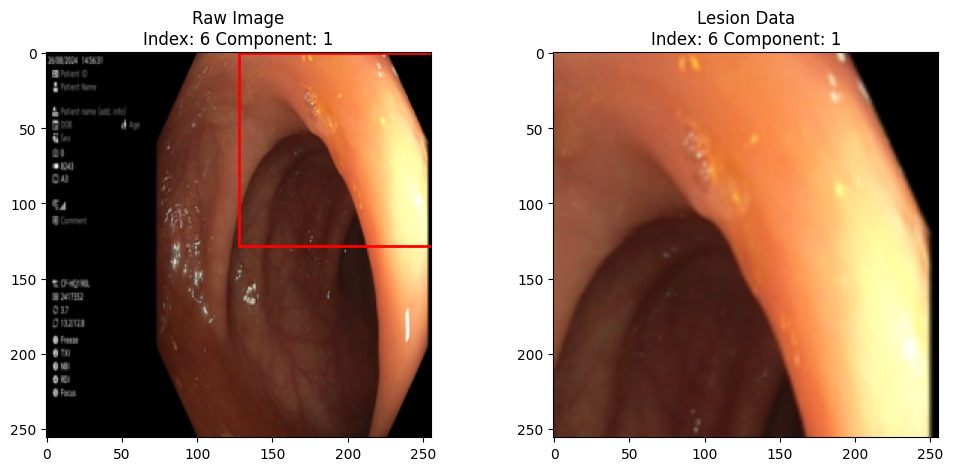

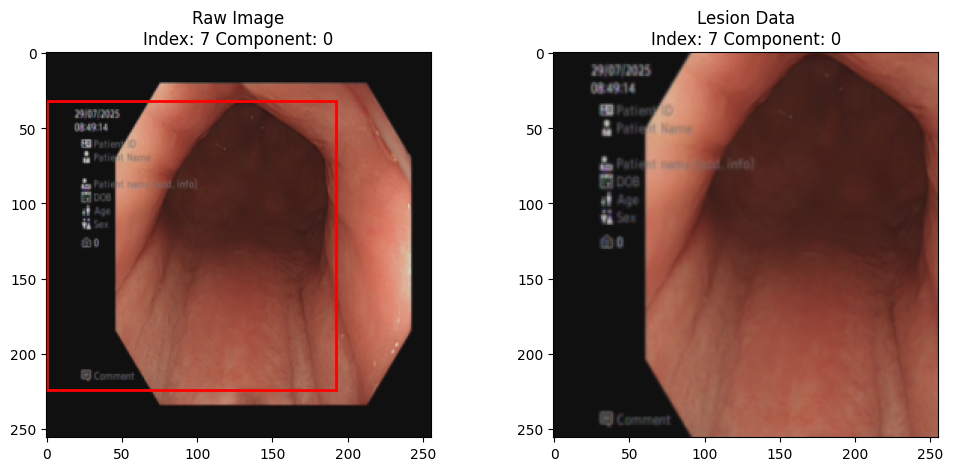

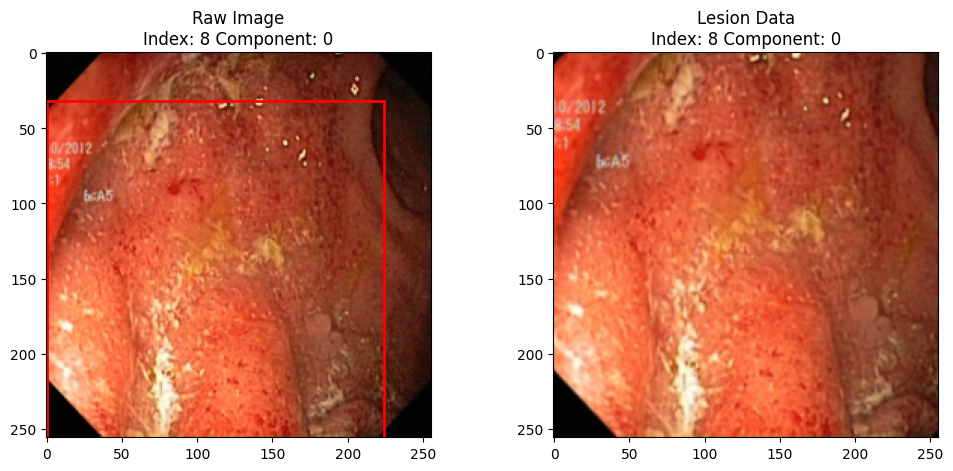

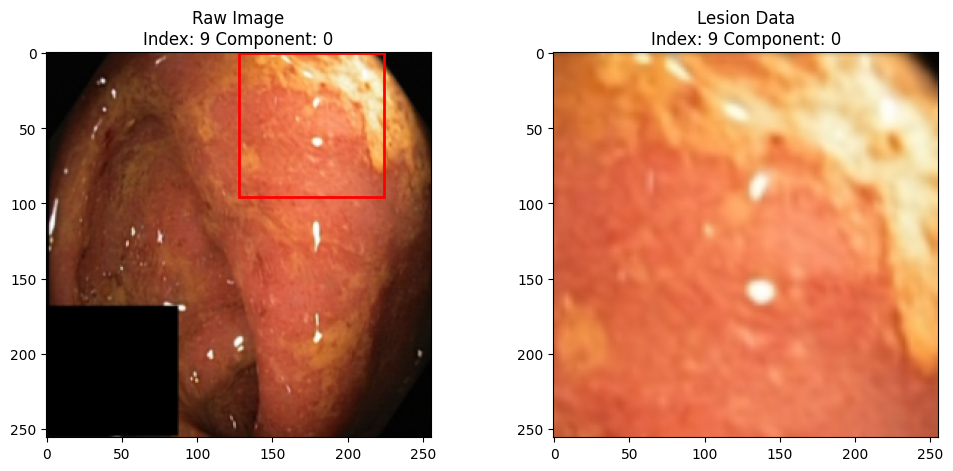

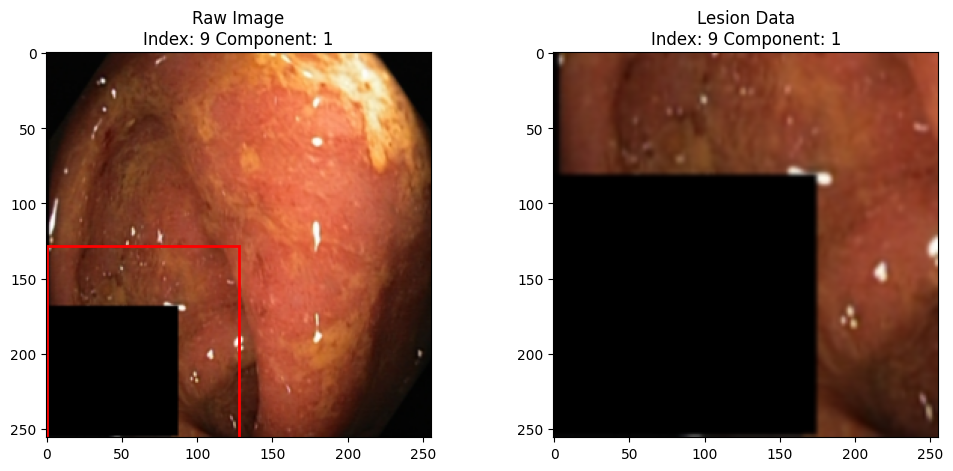

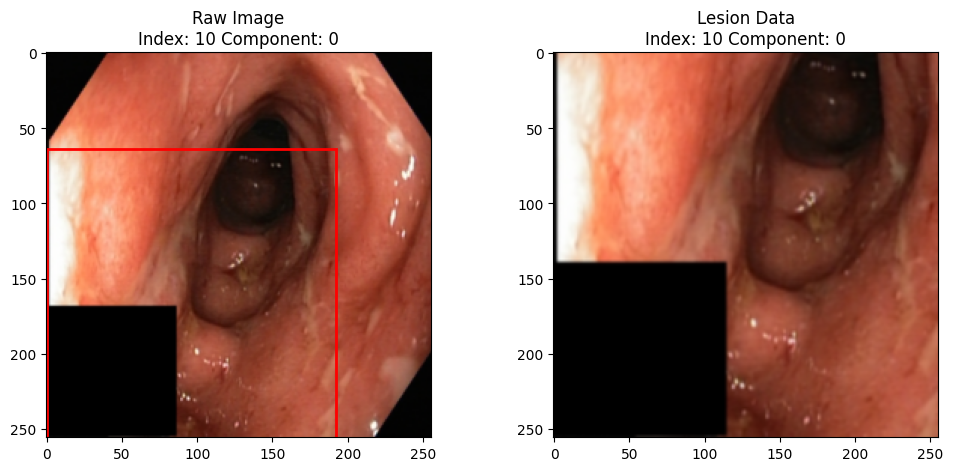

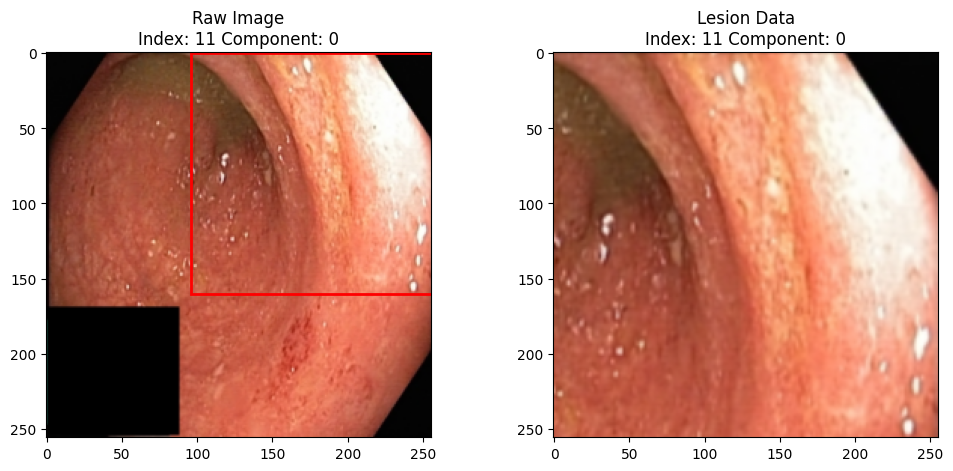

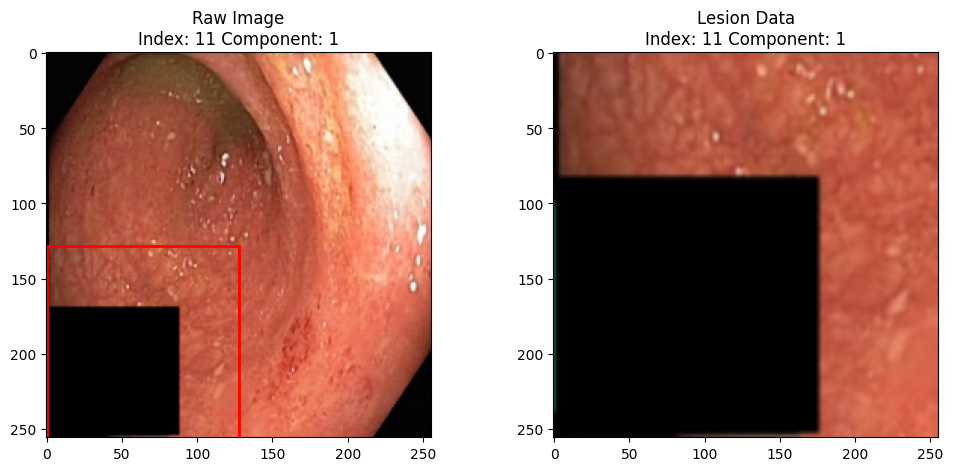

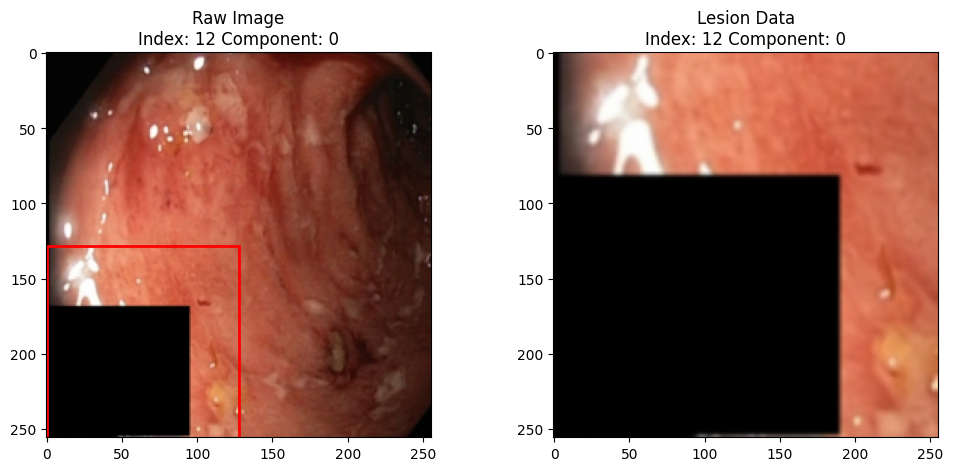

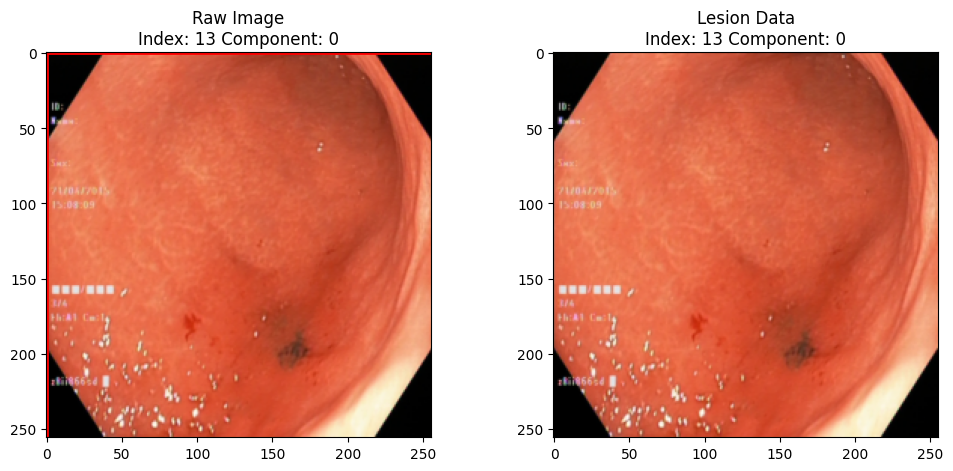

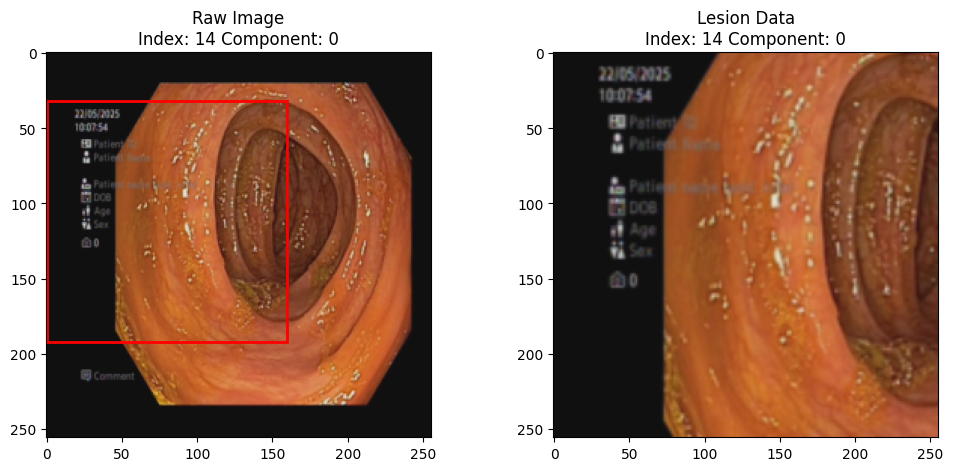

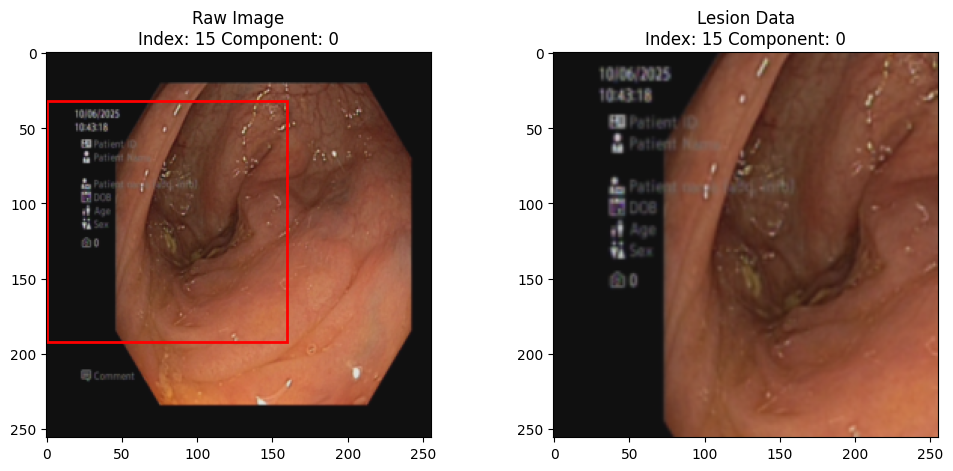

In [49]:
for index in range(len(lesion_candidates)):
    if len(lesion_candidates[index]) ==0:
        continue
    for candidate_index in range(len(lesion_candidates[index])):
        raw_img = raw[index]
        lesion_img = lesion_candidates[index][candidate_index]
        lesion_mask = lesion_candidate_masks[index][candidate_index]
        # Transpose the raw image to (224, 224, 3) for visualization
        raw_img = raw_img.permute(1, 2, 0)
        lesion_img = lesion_img.permute(1, 2, 0)

        coords = torch.nonzero(lesion_mask, as_tuple=False)
        y_min, x_min = coords.min(dim=0).values.tolist()
        y_max, x_max = coords.max(dim=0).values.tolist()
        box_width = x_max - x_min + 1
        box_height = y_max - y_min + 1

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        axs[0].imshow(raw_img.cpu().detach().numpy())
        axs[0].add_patch(
            Rectangle(
                (x_min, y_min),
                box_width,
                box_height,
                fill=False,
                edgecolor="red",
                linewidth=2,
            )
        )
        axs[0].set_title(f"Raw Image\nIndex: {index} Component: {candidate_index}")
        axs[1].imshow(lesion_img.cpu().detach().numpy())
        axs[1].set_title(f"Lesion Data\nIndex: {index} Component: {candidate_index}")
        plt.show()